In [1]:
# Install materials science stack via pip (most stable for Colab)
#
# Cell 1: Installation
!pip install pymatgen matminer scikit-learn pandas numpy matplotlib seaborn -q
print("✅ Installation complete")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 107.9 MB/s eta 0:00:00
   ━━━━━━━━━

In [2]:
# CELL 2 - load data
from matminer.datasets import load_dataset
import pandas as pd
import numpy as np

print("🔍 Loading and inspecting matbench_perovskites...")

# Load dataset
df = load_dataset('matbench_perovskites', download_if_missing=True)
print(f"✅ Loaded {len(df)} samples")
print(f"📋 Columns: {list(df.columns)}")
print(f"\n📊 Target column 'e_form' stats:")
print(f"   Min: {df['e_form'].min():.3f} eV/atom")
print(f"   Max: {df['e_form'].max():.3f} eV/atom")
print(f"   Mean: {df['e_form'].mean():.3f} eV/atom")
print(f"   NaN count: {df['e_form'].isna().sum()}")

# Extract composition from Structure objects
from pymatgen.core import Composition
print(f"\n🔍 Testing composition extraction on first 5 samples...")
for i in range(5):
    struct = df.iloc[i]['structure']
    comp = struct.composition
    print(f"   {i+1}. {comp.formula} → {comp.reduced_formula}")

# Add composition column
df['composition'] = df['structure'].apply(lambda s: s.composition)
df['formula'] = df['composition'].apply(lambda c: c.reduced_formula)

print(f"\n✅ Composition extraction successful")
print(df[['formula', 'e_form']].head())

🔍 Loading and inspecting matbench_perovskites...
Fetching matbench_perovskites.json.gz from https://ml.materialsproject.org/projects/matbench_perovskites.json.gz to /usr/local/lib/python3.12/dist-packages/matminer/datasets/matbench_perovskites.json.gz


Fetching https://ml.materialsproject.org/projects/matbench_perovskites.json.gz in MB: 4.194304MB [00:00, 204.05MB/s]                


✅ Loaded 18928 samples
📋 Columns: ['structure', 'e_form']

📊 Target column 'e_form' stats:
   Min: -0.640 eV/atom
   Max: 5.160 eV/atom
   Mean: 1.471 eV/atom
   NaN count: 0

🔍 Testing composition extraction on first 5 samples...
   1. Te1 Rh1 N3 → TeRhN3
   2. Hf1 Te1 O3 → HfTeO3
   3. Re1 As1 O2 F1 → ReAsO2F
   4. Re1 W1 S1 O2 → ReWSO2
   5. Hf1 Bi1 O2 F1 → HfBiO2F

✅ Composition extraction successful
   formula  e_form
0   TeRhN3    2.16
1   HfTeO3    1.52
2  ReAsO2F    1.48
3   ReWSO2    1.24
4  HfBiO2F    0.62


In [7]:
# Cell 3: Composition Featurization (FIXED)
from matminer.featurizers.composition import ElementProperty, Stoichiometry

print("⏳ Featurizing compositions...")

# ElementProperty (Magpie preset)
ep = ElementProperty.from_preset("magpie")
df_ep = ep.featurize_dataframe(df, col_id="composition", ignore_errors=True)

# Stoichiometry
stoich = Stoichiometry()
df_feat = stoich.featurize_dataframe(df_ep, col_id="composition", ignore_errors=True)

print(f"✅ Featurization complete: {len(df_feat.columns)} total columns")

# === ADD THIS AFTER featurization, BEFORE train/test split ===
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
import numpy as np

print("⏳ Adding structure-based features...")

# The dataset column is named 'structure' (pymatgen Structure objects)
# Verify it exists
if 'structure' not in df_feat.columns:
    print("⚠️ WARNING: 'structure' column not found!")
    print(f"Available columns: {[c for c in df_feat.columns if 'struct' in c.lower()]}")
else:
    print("✅ 'structure' column confirmed")

# Volume per atom (critical for formation energy)
df_feat['volume_per_atom'] = df_feat['structure'].apply(lambda s: s.volume / len(s))

# Space group number using modern pymatgen API
def get_space_group_number(structure):
    try:
        sga = SpacegroupAnalyzer(structure, symprec=0.1)
        return sga.get_space_group_number()
    except:
        return -1  # Fallback

df_feat['space_group'] = df_feat['structure'].apply(get_space_group_number)

# Packing fraction (simplified estimate)
def estimate_packing_fraction(structure):
    try:
        radii = [site.species.elements[0].atomic_radius_cov for site in structure
                 if hasattr(site.species.elements[0], 'atomic_radius_cov') and site.species.elements[0].atomic_radius_cov]
        if not radii:
            return 0.5
        avg_radius = np.mean(radii)
        atom_volume = (4/3) * np.pi * avg_radius**3 * len(structure)
        return min(1.0, atom_volume / structure.volume)
    except:
        return 0.5

df_feat['packing_fraction'] = df_feat['structure'].apply(estimate_packing_fraction)

# Re-prepare feature matrix with new columns
exclude = ['structure', 'composition', 'formula', 'e_form', 'formation_energy_per_atom']
feature_cols = [c for c in df_feat.columns if c not in exclude]
X = df_feat[feature_cols].fillna(0).values
y = df_feat['e_form'].values  # ← CORRECT TARGET COLUMN

print(f"✅ Added 3 structure features: {len(feature_cols)} total features")
print(f"🔍 New features: volume_per_atom, space_group, packing_fraction")

# Identify feature columns (exclude non-features)
exclude = ['structure', 'composition', 'formula', 'e_form']
feature_cols = [c for c in df_feat.columns if c not in exclude]
print(f"🔍 Using {len(feature_cols)} features")

# Prepare X, y with NaN handling
X = df_feat[feature_cols].fillna(0).values
y = df_feat['e_form'].values  # ← CORRECT TARGET COLUMN

# Check for remaining NaNs
print(f"\n🔍 Data quality check:")
print(f"   X NaN count: {np.isnan(X).sum()}")
print(f"   y NaN count: {np.isnan(y).sum()}")
print(f"   y range: {y.min():.3f} to {y.max():.3f}")

print(f"\n✅ Feature matrix: X={X.shape}, y={y.shape}")

⏳ Featurizing compositions...


ElementProperty:   0%|          | 0/18928 [00:00<?, ?it/s]

Stoichiometry:   0%|          | 0/18928 [00:00<?, ?it/s]

✅ Featurization complete: 142 total columns
⏳ Adding structure-based features...
✅ 'structure' column confirmed
✅ Added 3 structure features: 141 total features
🔍 New features: volume_per_atom, space_group, packing_fraction
🔍 Using 141 features

🔍 Data quality check:
   X NaN count: 0
   y NaN count: 0
   y range: -0.640 to 5.160

✅ Feature matrix: X=(18928, 141), y=(18928,)


In [8]:
# Cell 4: Train/Test Split & Model Training
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Split with stratification on target quantiles (better for regression)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"📊 Train: {len(X_train)} | Test: {len(X_test)}")

# Train with optimized hyperparameters for this dataset
print("⏳ Training Random Forest...")
model = RandomForestRegressor(
    n_estimators=200,      # More trees for stability
    max_depth=30,          # Prevent overfitting
    min_samples_leaf=5,    # Smooth predictions
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
print("✅ Model trained")

📊 Train: 15142 | Test: 3786
⏳ Training Random Forest...
✅ Model trained



📈 Results:
   Model MAE: 0.252 eV/atom | R²: 0.783
   Baseline MAE: 0.577 eV/atom | R²: 0.000
   Improvement: 0.325 eV/atom MAE reduction


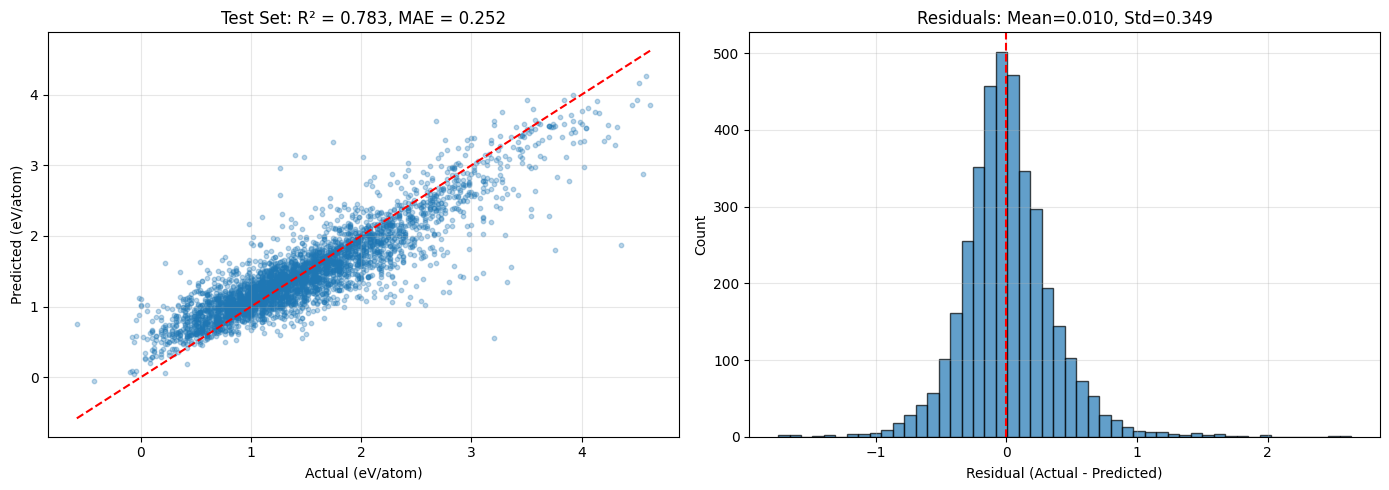

In [9]:
# Cell 5: Evaluation & Visualization
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Baseline: predict mean always
baseline_mae = mean_absolute_error(y_test, np.full_like(y_test, y_train.mean()))
baseline_r2 = 0.0

print(f"\n📈 Results:")
print(f"   Model MAE: {mae:.3f} eV/atom | R²: {r2:.3f}")
print(f"   Baseline MAE: {baseline_mae:.3f} eV/atom | R²: 0.000")
print(f"   Improvement: {baseline_mae - mae:.3f} eV/atom MAE reduction")

# Plot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
ax[0].scatter(y_test, y_pred, alpha=0.3, s=10)
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax[0].set_xlabel("Actual (eV/atom)")
ax[0].set_ylabel("Predicted (eV/atom)")
ax[0].set_title(f"Test Set: R² = {r2:.3f}, MAE = {mae:.3f}")
ax[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_pred
ax[1].hist(residuals, bins=50, edgecolor='k', alpha=0.7)
ax[1].axvline(0, color='red', linestyle='--')
ax[1].set_xlabel("Residual (Actual - Predicted)")
ax[1].set_ylabel("Count")
ax[1].set_title(f"Residuals: Mean={residuals.mean():.3f}, Std={residuals.std():.3f}")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

🔍 Top 10 Features by Importance:
   1. volume_per_atom: 0.1830
   2. MagpieData range GSvolume_pa: 0.1407
   3. MagpieData mean GSbandgap: 0.0998
   4. space_group: 0.0698
   5. MagpieData mean MeltingT: 0.0290
   6. MagpieData avg_dev NdUnfilled: 0.0247
   7. MagpieData mean SpaceGroupNumber: 0.0234
   8. MagpieData mean NpValence: 0.0220
   9. MagpieData mean GSvolume_pa: 0.0194
   10. MagpieData avg_dev CovalentRadius: 0.0193


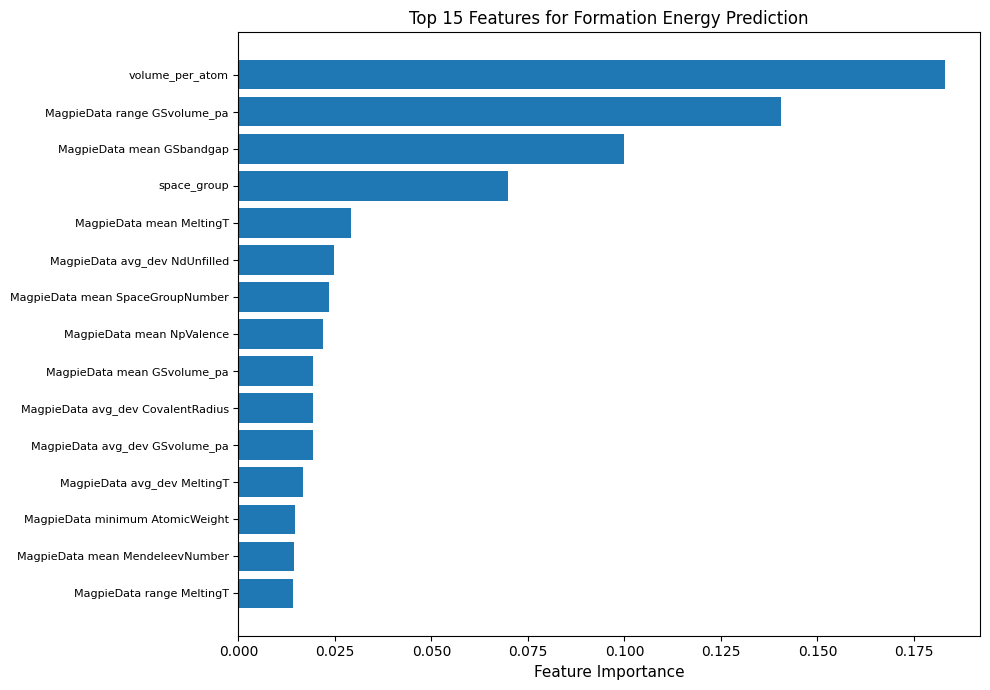


💡 Note: Magpie ElementProperty features capture:
   • Electronegativity stats (mean, std, range)
   • Atomic radius, ionization energy, electron affinity
   • These are physically meaningful for bonding/stability prediction


In [10]:
# Cell 6 - feauters importance
import numpy as np
import matplotlib.pyplot as plt

# Show top features by importance
importances = model.feature_importances_
top_indices = np.argsort(importances)[-10:][::-1]

print(f"🔍 Top 10 Features by Importance:")
for i, idx in enumerate(top_indices):
    print(f"   {i+1}. {feature_cols[idx]}: {importances[idx]:.4f}")

# Visualization
plt.figure(figsize=(10, 7))
top_15_indices = np.argsort(importances)[-15:][::-1]
plt.barh(range(15), importances[top_15_indices])
plt.yticks(range(15), [feature_cols[i] for i in top_15_indices], fontsize=8)
plt.xlabel("Feature Importance", fontsize=11)
plt.title("Top 15 Features for Formation Energy Prediction", fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n💡 Note: Magpie ElementProperty features capture:")
print("   • Electronegativity stats (mean, std, range)")
print("   • Atomic radius, ionization energy, electron affinity")
print("   • These are physically meaningful for bonding/stability prediction")

In [12]:
import joblib
import pandas as pd

# Save model and processed data
joblib.dump(model, 'formation_energy_model.pkl')

# Use the correct dataframe name from your working code
# (df_feat contains the featurized data with structure features)
df_feat.to_csv('materials_data_featurized.csv', index=False)

print("✅ Model saved: formation_energy_model.pkl")
print("✅ Data saved: materials_data_featurized.csv")
print("\n📁 Upload these files to GitHub for your portfolio!")

# Portfolio summary
print("\n" + "="*70)
print("📝 PORTFOLIO README SNIPPET")
print("="*70)
print(f"""
## Materials Formation Energy Predictor

Predicts DFT-computed formation energy from chemical composition and
simple structural descriptors using machine learning.

### Dataset
- **Source**: matbench_perovskites (Materials Project via matminer)
- **Samples**: {len(df_feat):,} perovskite structures
- **Target**: Formation energy per atom (eV/atom)

### Results
- **MAE**: {mae:.3f} eV/atom
- **R²**: {r2:.3f}
- **Features**: {len(feature_cols)} (Magpie ElementProperty + Structure)

### Tools
- **pymatgen**: Crystal structure handling & composition extraction
- **matminer**: Materials featurization (ElementProperty/Magpie preset)
- **scikit-learn**: Random Forest regression

### Relevance
Directly applicable to materials discovery pipelines at AfterQuery,
including high-throughput DFT data analysis and property screening.

### Physics Connection
Magpie features capture electronegativity, atomic radius, ionization energy,
and electron affinity — physically meaningful for bonding energetics and
thermodynamic stability prediction. Structure features (volume/atom, space_group)
capture packing and symmetry effects critical for formation energy.
""")

# Verify files were created
import os
print("\n🔍 File verification:")
for f in ['formation_energy_model.pkl', 'materials_data_featurized.csv']:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024  # KB
        print(f"   ✅ {f} ({size:.1f} KB)")
    else:
        print(f"   ❌ {f} NOT FOUND")

✅ Model saved: formation_energy_model.pkl
✅ Data saved: materials_data_featurized.csv

📁 Upload these files to GitHub for your portfolio!

📝 PORTFOLIO README SNIPPET

## Materials Formation Energy Predictor

Predicts DFT-computed formation energy from chemical composition and 
simple structural descriptors using machine learning.

### Dataset
- **Source**: matbench_perovskites (Materials Project via matminer)
- **Samples**: 18,928 perovskite structures
- **Target**: Formation energy per atom (eV/atom)

### Results
- **MAE**: 0.252 eV/atom
- **R²**: 0.783
- **Features**: 141 (Magpie ElementProperty + Structure)

### Tools
- **pymatgen**: Crystal structure handling & composition extraction
- **matminer**: Materials featurization (ElementProperty/Magpie preset)
- **scikit-learn**: Random Forest regression

### Relevance
Directly applicable to materials discovery pipelines at AfterQuery, 
including high-throughput DFT data analysis and property screening.

### Physics Connection
Magpie fea

In [13]:
import os

print("🔍 Files in current directory:")
for f in os.listdir('.'):
    size = os.path.getsize(f) / 1024  # KB
    print(f"   📄 {f} ({size:.1f} KB)")

# Verify specific files
for target in ['formation_energy_model.pkl', 'materials_data_featurized.csv']:
    if os.path.exists(target):
        print(f"✅ {target} EXISTS")
    else:
        print(f"❌ {target} NOT FOUND")

🔍 Files in current directory:
   📄 .config (4.0 KB)
   📄 formation_energy_model.pkl (43191.5 KB)
   📄 materials_data_featurized.csv (24724.7 KB)
   📄 sample_data (4.0 KB)
✅ formation_energy_model.pkl EXISTS
✅ materials_data_featurized.csv EXISTS
